This page presents the analytical steps following exploratory data analysis (EDA) and data pre-processing shown in the [previous page](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/). The next step in our analytical pipeline is to explore and compare modelling approaches. Here, I cover how to **create a logistic regression model** to predict whether a person will pay a loan back. 

I've chosen logistic regression as my initial model because it's a well-known and understood methodology. The idea is to compare this 'classic' model with other approaches to arrive at an optimal model, understanding advantages and drawbacks of using a method over another.   

I'll be using `scikit-learn` along other packages shown below. The specific environment used for the entire project is available [here](https://github.com/znogbes/kaggle-predicting-loan-payback/blob/main/environment.yml).

In [2]:
# set up
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# ml methods
from sklearn.model_selection import train_test_split, cross_validate, \
    cross_val_predict, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, confusion_matrix,\
    ConfusionMatrixDisplay, classification_report

## Import processed data

Previously, I **encoded the raw data** obtained from Kaggle to make sure it was **fit for machine learning**. Here, I export it form a local directory and check the features after encoding.



In [3]:
# read encoded data
data_encoded = pd.read_csv('./data/data_train_processed.csv')
# the data_test.csv provided by kaggle doesn't have labels
# so data for splitting, model training, and testing will come from 'data_train'
# make a copy of encoded data to use for modelling
data = data_encoded.copy()
# make all data float type #??? CHECK THIS !!!
# data = data.astype(float)
# check encoded version of data is what has been uploaded
features = sorted(data.columns)

<details markdown="1">
<summary><b>Show all 31 features</b></summary>

In [4]:
features

['annual_income',
 'credit_score',
 'debt_to_income_ratio',
 "education_level_Bachelor's",
 'education_level_High School',
 "education_level_Master's",
 'education_level_Other',
 'education_level_PhD',
 'employment_status_Employed',
 'employment_status_Retired',
 'employment_status_Self-employed',
 'employment_status_Student',
 'employment_status_Unemployed',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'grade_subgrade',
 'interest_rate',
 'loan_amount',
 'loan_paid_back',
 'loan_purpose_Business',
 'loan_purpose_Car',
 'loan_purpose_Debt consolidation',
 'loan_purpose_Education',
 'loan_purpose_Home',
 'loan_purpose_Medical',
 'loan_purpose_Other',
 'loan_purpose_Vacation',
 'marital_status_Divorced',
 'marital_status_Married',
 'marital_status_Single',
 'marital_status_Widowed']

</details>

## Pre-modelling steps

### Separate features and labels

We'll begin by saving the predicting variables (features) in a separate data object from the labels (payers *vs.* non-payers) 

In [5]:
# separate features and labels (outcome) 
X = data.drop('loan_paid_back', axis=1)
y = data['loan_paid_back']

### Split data

Before we go into any models, it's crucial to split the data into training/validation and testing sets. We'll use **80% of the data for training/validation**, and the remaining **20% for testing**. We use this approach so the final model can be used on data it hasn't seen before (i.e., the testing set), which gives us an idea of whether overfitting is occurring. Note that `train_test_split()` **stratifies the data**, which means the [label imbalance](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/#class-balance) (*payer vs. non payers*) observed in the global data set is **preserved** in the training/validation and test sets.   

In [6]:
# data splits: training, validation, and testing 
# (80% for training/validation, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=17)

### Standardise data

As you might have noticed in the [histograms](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/#histograms) and [boxplots](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/#box-plots) produced during EDA, we have **data in different numeric scales**. For instance, `annual_income` and `loan_amount` are expressed in thousands whereas `intesrest_rate` is expressed as a percentage. 

To account for the different ranges in these numeric scales, we will **standardise** the data objects containing training and testing features. After standardisation, the **mean of our numeric data will be 0** and the **standard deviation will be 1**. Note that standardisation is applied to both training and testing feature sets, but **the scaler object applied to both sets is based on the training data**.

In [7]:
# function to standardise data (mean = 0, stdev = 1)
def standardise_data(X_train, X_test):
    # intialise scaling object 
    sc = StandardScaler()
    # set on the training set
    sc.fit(X_train)
    # apply scaler
    train_std = sc.fit_transform(X_train)
    test_std = sc.fit_transform(X_test)
    return train_std, test_std

X_train_std, X_test_std = standardise_data(X_train, X_test)

## Fit logistic regression

### K-fold cross validation

Below, we create a model object with the method of our choice, in this case logistic regression. Note that we set a `class_weight` argument within the model to account for the [imbalance between classes](https://znogbes.github.io/sebastian-gonzalez-portfolio//portfolio/portfolio-1/#class-balance) observed during EDA. This argument applies weights to each class as specified in the `scikit-learn` [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). 

We **fit that model using the standardised features** and the **labels from the training/validation set**. Note that we use *k-fold cross validation* to randomly **shuffle our training/validation data** k-number of times. In this case, the regression will be run 10 times, each time using a different section of the data set for training and another for validation. The model will be tested on the validation set so it can return performance metrics, which we can average across the 10 runs. We can also set the `cross_validate()` method to return the generated models so we can extract coefficients.

In [8]:
# start modelling
# approach 1 - logistic regressions
model = LogisticRegression(class_weight='balanced')

# defaulted to stratified cross validation (cv) - i.e., percentage of sample 
# in each label is kept consistent as possible
cv_results = cross_validate(
    model, X_train_std, y_train,
    # performance metrics to calculate
    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    n_jobs=-1,
    # number of folds
    cv=10,
    # return trained models for each fold
    return_estimator=True # increases running time a little
    )

### Extract coefficients

Using the generated models stored in our cross-validation results, we can calculate the mean coefficient for every feature across all 10 runs of the logistic regression. We can then create a table with every feature and its average coefficient. If you get the absolute value of the coefficients and sort them in descending order, you will see which features had the largest effect at predicting loan payback, regardless of whether that effect was positive or negative. I'll present the 10 features with the greatest influence, but feel free to check the rest by clicking on the arrow.

In [9]:
# extract coefficients from models generated in cross val
co_eff_df = pd.DataFrame()
co_eff_df['feature'] = list(X_train.columns)

coefficients = []
for model in cv_results['estimator']:
    # append array of coefficients
    coefficients.append(model.coef_[0])

# calculate mean coefficient for every feature
mean_coefficients = np.mean(coefficients, axis = 0)
# save into coeff df
co_eff_df['mean_coefficient_cv10'] = mean_coefficients
# sort by absolute value (derived from mean coeff to understand magnitude)
co_eff_df['co_efficient_abs'] = np.abs(co_eff_df['mean_coefficient_cv10'])
co_eff_df.sort_values(by='co_efficient_abs', ascending=False, inplace=True)
# present 10 top features by absolute coefficient value
co_eff_df[0:10]

,feature,mean_coefficient_cv10,co_efficient_abs
22,employment_status_Unemployed,-1.193945,1.193945
1,debt_to_income_ratio,-0.911103,0.911103
2,credit_score,0.891188,0.891188
19,employment_status_Retired,0.819979,0.819979
18,employment_status_Employed,0.448938,0.448938
21,employment_status_Student,-0.317935,0.317935
20,employment_status_Self-employed,0.295849,0.295849
5,grade_subgrade,0.106203,0.106203
4,interest_rate,-0.057440,0.057440
27,loan_purpose_Home,0.030958,0.030958


<details markdown="1">
<summary><b>Show all feature coefficients (31)</b></summary>

In [10]:
co_eff_df

,feature,mean_coefficient_cv10,co_efficient_abs
22,employment_status_Unemployed,-1.193945,1.193945
1,debt_to_income_ratio,-0.911103,0.911103
2,credit_score,0.891188,0.891188
19,employment_status_Retired,0.819979,0.819979
18,employment_status_Employed,0.448938,0.448938
21,employment_status_Student,-0.317935,0.317935
20,employment_status_Self-employed,0.295849,0.295849
5,grade_subgrade,0.106203,0.106203
4,interest_rate,-0.057440,0.057440
27,loan_purpose_Home,0.030958,0.030958


</details>

## Model evaluation

### Confusion matrix

Evaluation metrics of model performance assess correct *vs.* incorrect predictions of a model. Before diving into specific metric evaluation, you can make a visual assessment of model performance via a confusion matrix. We can plot the rates of true positives and true negatives (i.e., the correct predictions) and the rate of false positives and false negatives (i.e., the incorrect predictions). To compute these rates, we need to compare model predictions *vs.* actual labels in the data. The `ConfusionMatrixDisplay()` and `from_estimator()` methods can do just that!

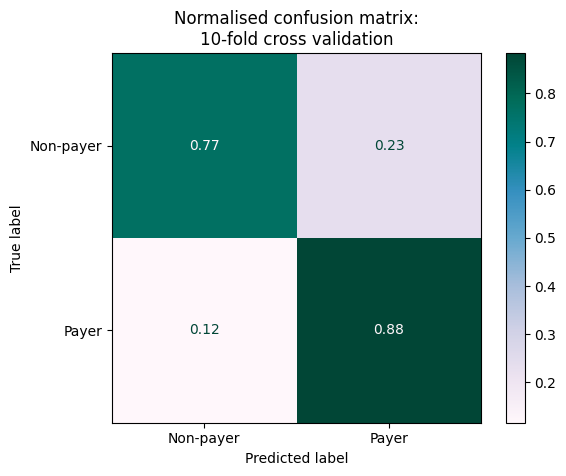

In [11]:
ConfusionMatrixDisplay.from_estimator(model, X_train_std, y_train, 
                                      display_labels=['Non-payer','Payer'],
                                      cmap='PuBuGn',
                                      normalize='true')
plt.title('Normalised confusion matrix:\n10-fold cross validation')
plt.show()

Our logistic regression does well at predicting *loan payers*: **88% of those predicted to be a payer were indeed one** *vs* 12% predicted not to be a payer, who actually did pay back (i.e., false negatives). In contrast, 77% of non-payers were predicted correctly, but **23% were wrongly assigned to the payer group**. In a real world scenario, this **false positive rate** would have important **financial implications:** 23% represents 22,081 loans that were not paid back but the model predicted were paid. Imagine if each loan was worth £5,000 on average! 

We'll see below that logistic regression performs well overall, but we would still benefit from further tuning or other methods to address the false positive rate.


### Performance metrics

Along with the 10 logistic regressions, the `cross_validate()` method returned 4 performance metrics: `accuracy`, `precision`, `recall`, and `F1 score`. Each of these metrics was calculated 10 times, each time by testing the generated model on the validation set for the corresponding k-fold. Since the initial `model` object was a logistic regression weighted to account imbalanced classes, I deemed appropriate to request **performance metrics that also weighted class imbalance**. We can plot the distributions of those metrics across the 10 runs in a boxplot.

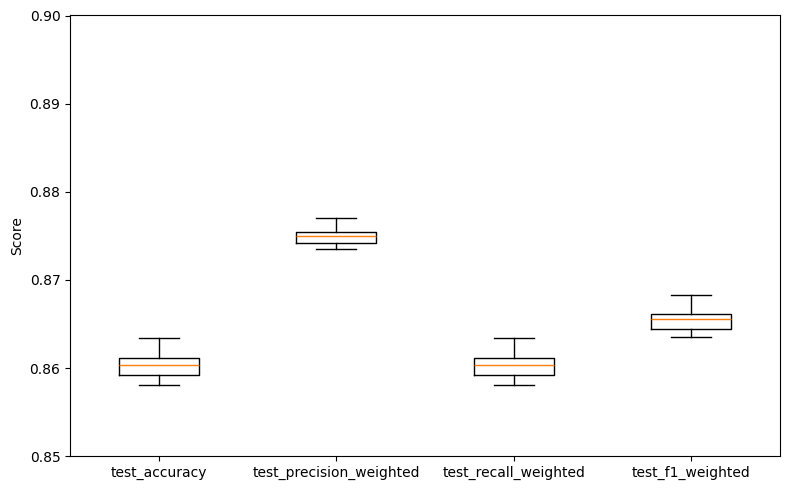

In [12]:
# plot distribution of performance metrics shown in classification report
performance_metrics = pd.DataFrame(cv_results).drop(
    columns=['fit_time', 'score_time', 'estimator'])

# plot metrics obtained via stratified kfolds
# the test_ metrics refer to the the 10th fold 
plt.subplots(figsize=(8,5))
plt.boxplot(performance_metrics, labels=performance_metrics.columns)
plt.ylim(0.85, 0.9)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

The plot suggests the **performance scores were relatively stable between model runs** for all measures of interest, given the narrow range between the boxes' whiskers. We have **generally good scores** across measures (>0.85) but it's still worth going through them. 

The model was generally accurate (i.e., the proportion of correctly classified labels was high), but that alone mustn't be used to interpret performance - which is why precision, recall, and F1 scores are needed. 

**The model was more precise than sensitive**, which means it was better at labelling payers correctly (when it made a prediction) than it was at finding all cases of payers in the data. This all boils down to having **more false negatives than false positives**, which we can see in the non-normalised confusion matrix below. 

The F1 score balances precision and recall, so it will be more useful when we compare modelling methods. More information about the methodology used to apply weights to these measures is available [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html). 

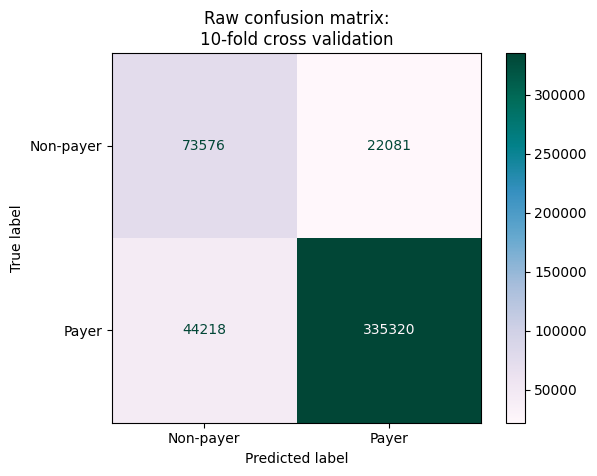

In [13]:
ConfusionMatrixDisplay.from_estimator(model, X_train_std, y_train, 
                                      display_labels=['Non-payer','Payer'],
                                      cmap='PuBuGn'
                                      )
plt.title('Raw confusion matrix:\n10-fold cross validation')
plt.show()


### ROC curve

Using a receiving operator characteristic (ROC) curve, we can **plot the true positive rate against the false positive rate**, as well as calculate AUC (area under the curve). Making a ROC curve plot is **useful to see how the model fares against randomness**. The dotted line in the plot represents a random classifier, that is a scenario where a model is no better at predicting outcomes than random chance. It is useful to plot this line as a benchmark. The more the ROC curve approaches the top left corner of the plot, the closer the model is to be a perfect classifier. 

Overall, our logistic regression fares well using this assessment, but **there could still be room for improvement**, which we might achieve in other models.

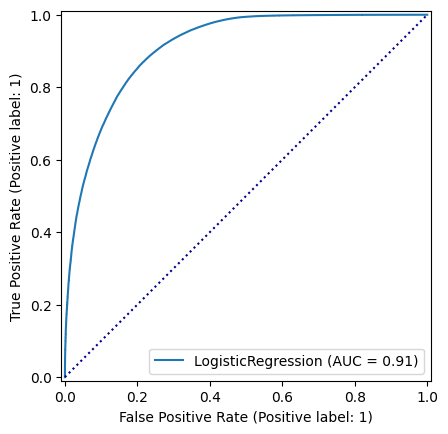

In [14]:
# receiver operator characteristic curve
# plot specificity (false positive rate) vs recall (aka sensitivity; true positive rate) 
roc_curve = RocCurveDisplay.from_estimator(model, X_train_std, y_train, pos_label=1)
fig = roc_curve.figure_
ax = roc_curve.ax_
# plot chance
ax.plot([0,1], [0,1], color='darkblue', linestyle=':')
plt.show()

## SMOTE for class imbalance

We accounted for the imbalance between payers and non-payers by using *class weights* when we fitted our logistic regressions. That approach delivered a reasonable model. However, the false positive rate we observed would have business implications that we couldn't ignore in a in real-life scenario.

Another avenue to account for class imbalance in ML is using **SMOTE** (*Synthetic Minority Oversampling Technique*). We will be using SMOTE to augment the number of non-payers observation in our training data. I will go through the steps needed to apply SMOTE below, but you can read more about the theory behind it [here](https://www.jair.org/index.php/jair/article/view/10302).

In [15]:
# import SMOTE package
import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import NearestNeighbors

We'll be using the training objects created earlier. Remember these come from one-hot encoded data. By using the encoding data, SMOTE can generate synthetic data points for encoded categorical variables such as `employment_status` as floating point values between data points in a multidimensional space. SMOTE will be finding near-neighbour points in the original data. EXPLAIN BETTER.

In [16]:
# count numbers in each class in the training set
n_non_payers = np.sum(y_train == 0)
n_payers = np.sum(y_train == 1)

# number of samples to generate to balance classes (i.e., 15% over the total number of payers)
n_samples_to_generate = int((n_payers*1.15).round())

We'll be generating {{n_samples_to_generate}} total samples. SMOTE will use the original data first and top up to our desired number of samples by generating synthetic data.

In [17]:
y_train.value_counts()

loan_paid_back
1.0    379538
0.0     95657
Name: count, dtype: int64

In [18]:
# turn all train to float before SMOTE
X_train = X_train.astype('float')

In [19]:
# apply SMOTE
# this method automatically generates synthetic data for the minority class, 
# but no synthetic data for the majority class
# X_train_smote, y_train_smote = SMOTE(random_state=17).fit_resample(X_train, y_train)

In [20]:
# apply SMOTE
# this method automatically generates synthetic data for the minority class, 
X_train_smote, y_train_smote = SMOTE(
    sampling_strategy={0:n_samples_to_generate, 1:n_samples_to_generate}
    ).fit_resample(X_train, y_train)

In [21]:
# this shows why we need to do further processing - because one hot encoded columns
X_train_smote.tail(10)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,grade_subgrade,gender_Female,gender_Male,gender_Other,marital_status_Divorced,...,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
872928,25547.552785,0.062622,723.838922,5762.997526,9.425796,13.895135,0.000000,1.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.0
872929,66513.215080,0.092973,726.222049,20143.853524,11.285962,14.000000,1.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.0
872930,92848.833548,0.066000,567.103233,9132.367829,13.947968,27.796773,0.970968,0.029032,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,0.970968,0.0,0.0,0.0,0.029032,0.0
872931,19194.736123,0.077612,675.816334,13383.675350,13.440415,12.938778,1.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.938778,0.061222,0.0,0.0,0.0,0.000000,0.0
872932,26117.881679,0.096538,604.109189,7103.628264,13.901265,23.956324,1.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.978162,0.000000,0.021838,0.0,0.0,0.0,0.000000,0.0
872933,39602.580000,0.087262,652.733492,25248.603700,13.682314,14.613325,0.462225,0.537775,0.0,0.537775,...,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.0
872934,91845.882801,0.097081,638.727575,13236.151638,13.810242,17.205912,0.000000,1.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.0
872935,17499.076346,0.050389,721.230341,16863.257095,11.588381,10.209991,0.209991,0.790009,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.0
872936,43775.327484,0.107273,662.680235,10680.940325,12.571657,15.361918,0.000000,1.000000,0.0,0.000000,...,0.0,0.0,0.234012,0.000000,0.000000,0.0,0.0,0.0,0.765988,0.0
872937,61346.541915,0.071750,667.884622,6130.994802,13.449039,15.596148,1.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.519230,0.480770,0.0,0.0,0.0,0.000000,0.0


In [22]:
# processing of smote data
data_encoded.dtypes.unique()

array([dtype('float64'), dtype('int64'), dtype('bool')], dtype=object)

In [23]:
# create objects containing variable names by type
col_names = X.columns
type(col_names)
# create filters based on type
mask_float = X.dtypes == 'float64'
# get names of float columns
float_cols = col_names[mask_float]
# repeat for integer and boolean 
mask_int = X.dtypes == 'int64'
int_cols = col_names[mask_int]
mask_bool = X.dtypes == 'bool'
bool_cols = col_names[mask_bool]

In [24]:
# function to perform one-hot encoding for boolean columns

def cast_one_hot_encoding(df, col_pattern):
    """
    transforms selected columns into one-hot encoded columns 
    by setting 1 for the highest value and 0 for the rest.
    """
    # Filter columns that match col_pattern
    filtered_cols = [col for col in df.columns if col_pattern in col]
    
    print(f'These variables were identified based on col_pattern provided:\n {filtered_cols}')
    
    # Find the index of the maximum value for each row across the filtered columns
    max_idx = df[filtered_cols].idxmax(axis=1)

    # create an array of zeros with the same shape as the filtered columns
    zeros_array = np.zeros_like(df[filtered_cols], dtype=int)
    
    # map column names by assigning indices
    col_index_map = {col: idx for idx, col in enumerate(filtered_cols)}
    max_idx_int = max_idx.map(col_index_map)

    # replace one the zeros i nthe array with 1 at the position of the maximum value
    zeros_array[np.arange(len(df)), max_idx_int] = 1
    # this is now the encoded array
    encoded_array = zeros_array

    # replace the original columns with the one-hot encoded values
    df[filtered_cols] = encoded_array
    
    return df

In [58]:
patterns = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose']

# now loop through boolean columns and apply one hot encoding function
for pattern in patterns:
    X_train_smote_processed = cast_one_hot_encoding(X_train_smote, pattern)    

# use another loop to set types to float and integer columns 
for col in col_names:
    if col in float_cols:
        # keep float type as is
        X_train_smote_processed[col] = X_train_smote_processed[col].astype(float)
    elif col in int_cols or col in bool_cols:
        # round integers / turn from int32 to int64 for boolean cols
        X_train_smote_processed[col] = X_train_smote_processed[col].round().astype('int64')

These variables were identified based on col_pattern provided:
 ['gender_Female', 'gender_Male', 'gender_Other']
These variables were identified based on col_pattern provided:
 ['marital_status_Divorced', 'marital_status_Married', 'marital_status_Single', 'marital_status_Widowed']
These variables were identified based on col_pattern provided:
 ["education_level_Bachelor's", 'education_level_High School', "education_level_Master's", 'education_level_Other', 'education_level_PhD']
These variables were identified based on col_pattern provided:
 ['employment_status_Employed', 'employment_status_Retired', 'employment_status_Self-employed', 'employment_status_Student', 'employment_status_Unemployed']
These variables were identified based on col_pattern provided:
 ['loan_purpose_Business', 'loan_purpose_Car', 'loan_purpose_Debt consolidation', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other', 'loan_purpose_Vacation']


In [65]:

# separate original from synthetic data
X_train_synthetic = X_train_smote_processed[len(X_train):]
y_train_synthetic = y_train_smote[len(y_train):]

# this tells us the amount of synthetic data generated for each class
y_train_synthetic.value_counts()

loan_paid_back
0.0    340812
1.0     56931
Name: count, dtype: int64

In [27]:
# deduplicate synthetic data
# standardise real and synthetic data (standardise based on data in the real
# training data)
X_train_std, X_train_synth_std = standardise_data(X_train, X_train_synthetic)

# Get ALL real X data (combine standardised training + test data)
# We do this because we need to check for duplicates / very close
# values in ALL of the real data we've got
X_real_std = np.concatenate([X_train_std, X_test_std], axis=0)

# below will take a couple of minutes to run
# find nearest neighbour in the real data for each synthetic data point
# i think smote uses 6 neighbours by defaults - double check
nn = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(X_real_std)
dists, idxs = nn.kneighbors(X_train_synth_std)

In [75]:
# store the distances and indices of nearest neighbours
X_train_synthetic['nearest_neighbour_distance'] = list(dists.flatten())
X_train_synthetic['nearest_neighbour_index_real_data'] = list(idxs.flatten())

C:\TEMP\ipykernel_8960\2000544634.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_synthetic['nearest_neighbour_distance'] = list(dists.flatten())
C:\TEMP\ipykernel_8960\2000544634.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_synthetic['nearest_neighbour_index_real_data'] = list(idxs.flatten())


In [76]:
# make data frame of all synthetic data (features and labels)
data_train_synthetic = pd.concat([X_train_synthetic, y_train_synthetic], axis=1)
# sort by furthest distance to nearest neighbour in real data
data_train_synthetic.sort_values(by='nearest_neighbour_distance', ascending=False, inplace=True)
data_train_synthetic.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,grade_subgrade,gender_Female,gender_Male,gender_Other,marital_status_Divorced,...,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,nearest_neighbour_distance,nearest_neighbour_index_real_data,loan_paid_back
849148,62726.988470,0.146939,650,1536.814245,12.935017,17,1,0,0,0,...,0,1,0,0,0,0,0,8.455463,48712,1.0
850992,22497.685301,0.211596,729,29165.107862,10.490630,10,0,1,0,0,...,0,0,0,0,1,0,0,8.441365,474392,1.0
734963,132178.538094,0.247730,697,17434.022496,12.105932,15,1,0,0,0,...,0,0,1,0,0,0,0,8.430787,381062,0.0
864783,26563.355986,0.163807,658,4287.746612,14.730323,16,0,1,0,0,...,0,0,0,0,0,0,1,8.423513,259638,1.0
821631,16251.949904,0.045487,773,13185.022290,8.565875,5,1,0,0,0,...,0,0,0,0,0,1,0,8.415710,211363,1.0


In [66]:
y_train_synthetic.value_counts()

loan_paid_back
0.0    340812
1.0     56931
Name: count, dtype: int64

In [100]:
# drop synthetic data where label was payer, as this is the majority class 
data_train_synthetic = data_train_synthetic[data_train_synthetic['loan_paid_back'] == 0]
data_train_synthetic['loan_paid_back'].value_counts()

# calculate how many synthetic data points to keep for non-payers (the minority class in original train data)
n_original_non_payers = (y_train == 0).sum()
n_original_payers = (y_train == 1).sum()
# this is the number of synthetic, non-payer data points needed to balance the classes
n_keep = n_original_payers-n_original_non_payers

In [101]:
# remove synthetic data points based on proximity to real data points
data_train_synthetic_final = data_train_synthetic.head(n_keep)
data_train_synthetic_final['loan_paid_back'].value_counts()
data_train_synthetic_final['is_synthetic'] = True

C:\TEMP\ipykernel_8960\4243722455.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train_synthetic_final['is_synthetic'] = True


In [103]:
data_training_after_smote = pd.concat([X_train, y_train], axis=1)
data_training_after_smote['is_synthetic'] = False
data_training_after_smote['loan_paid_back'].value_counts()

loan_paid_back
1.0    379538
0.0     95657
Name: count, dtype: int64

In [104]:
data_training_after_smote = pd.concat([data_training_after_smote, data_train_synthetic_final], axis=0)
data_training_after_smote['loan_paid_back'].value_counts()

loan_paid_back
1.0    379538
0.0    379538
Name: count, dtype: int64

In [106]:
data_training_after_smote['is_synthetic'].value_counts()
# write to csv for use in modelling
data_training_after_smote.to_csv('./data/data_training_processed_after_smote.csv', index=False)

In [107]:
data_training_after_smote.columns

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'grade_subgrade', 'gender_Female', 'gender_Male',
       'gender_Other', 'marital_status_Divorced', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_Bachelor's', 'education_level_High School',
       'education_level_Master's', 'education_level_Other',
       'education_level_PhD', 'employment_status_Employed',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'loan_purpose_Business', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation', 'loan_paid_back', 'is_synthetic',
       'nearest_neighbour_distance', 'nearest_neighbour_index_real_data'],
      dtype='object')

In [ ]:
# repeat logistic regression modelling with SMOTE data
data_training_augmented = data_training_after_smote.drop(columns=['is_synthetic', 
                                        'nearest_neighbour_distance', 
                                        'nearest_neighbour_index_real_data'])

X_train_augmented = data_training_augmented.drop('loan_paid_back', axis=1)
y_train_augmented = data_training_augmented['loan_paid_back']

In [ ]:

# standardise data
X_train_aug_std, X_test_std = standardise_data(X_train_augmented, X_test)

# choose model
model = LogisticRegression()

# defaulted to stratified cross validation (cv) - i.e., percentage of sample 
# in each label is kept consistent as possible
cv_results = cross_validate(
    model, X_train_aug_std, y_train_augmented,
    # performance metrics to calculate
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    n_jobs=-1,
    # number of folds
    cv=10,
    # return trained models for each fold
    return_estimator=True # increases running time a little
    )

# extract coefficients from models generated in cross val
co_eff_df = pd.DataFrame()
co_eff_df['feature'] = list(X_train.columns)

coefficients = []
for model in cv_results['estimator']:
    # append array of coefficients
    coefficients.append(model.coef_[0])

# calculate mean coefficient for every feature
mean_coefficients = np.mean(coefficients, axis = 0)
# save into coeff df
co_eff_df['mean_coefficient_cv10'] = mean_coefficients
# sort by absolute value (derived from mean coeff to understand magnitude)
co_eff_df['co_efficient_abs'] = np.abs(co_eff_df['mean_coefficient_cv10'])
co_eff_df.sort_values(by='co_efficient_abs', ascending=False, inplace=True)
# present 10 top features by absolute coefficient value
co_eff_df[0:10]

In [ ]:
ConfusionMatrixDisplay.from_estimator(model, X_train_smote_std, y_train_smote1, 
                                      display_labels=['Non-payer','Payer'],
                                      cmap='PuBuGn',
                                      normalize='true'
                                      )
plt.title('Normalised confusion matrix:\n10-fold cross validation & SMOTE')
plt.show()

In [ ]:
# plot distribution of performance metrics shown in classification report
performance_metrics = pd.DataFrame(cv_results).drop(
    columns=['fit_time', 'score_time', 'estimator'])

# plot metrics obtained via stratified kfolds
# the test_ metrics refer to the the 10th fold 
plt.subplots(figsize=(8,5))
plt.boxplot(performance_metrics, labels=performance_metrics.columns)
#plt.ylim(0.85, 0.9)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

In [ ]:
# receiver operator characteristic curve
# plot specificity (false positive rate) vs recall (aka sensitivity; true positive rate) 
roc_curve = RocCurveDisplay.from_estimator(model, X_train_smote_std, y_train_smote1, pos_label=1)
fig = roc_curve.figure_
ax = roc_curve.ax_
# plot chance
ax.plot([0,1], [0,1], color='darkblue', linestyle=':')
plt.show()

**Next, I will test other ML approaches** and compare them against our baseline results from fitting a logistic regression.